# 09 — Feature sensitivity analysis

**Goal:** Analyze how model predictions respond to changes in environmental variables.

We train a LightGBM on **total_alkalinity**, then for each key variable (precipitation, elevation, NDVI, clay, temperature_2m) we vary it over its observed range while holding others at the median, predict, and plot **response curves** (x = variable, y = predicted target).

# 1. Train baseline model

Load the dataset (same preprocessing as in previous notebooks), build the feature matrix, and train a **LightGBM** model on **all data** for target **total_alkalinity**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))

from src.features.preprocess import feature_columns, impute_median

RAW = ROOT / "data" / "raw"
csv_path = RAW / "water_quality_dataset_v1.csv"
if not csv_path.exists():
    csv_path = RAW / "water_quality.csv"
if not csv_path.exists():
    raise FileNotFoundError("No water_quality_dataset_v1.csv or water_quality.csv in data/raw.")

df = pd.read_csv(csv_path)
if "Latitude" in df.columns and "lat" not in df.columns:
    df["lat"] = df["Latitude"]
if "Longitude" in df.columns and "lon" not in df.columns:
    df["lon"] = df["Longitude"]
for old, new in [("Total Alkalinity", "total_alkalinity"), ("Electrical Conductance", "electrical_conductance"), ("Dissolved Reactive Phosphorus", "dissolved_reactive_phosphorus")]:
    if old in df.columns and new not in df.columns:
        df[new] = df[old]

TARGET = "total_alkalinity"
if TARGET not in df.columns:
    TARGET = [c for c in ["total_alkalinity", "electrical_conductance", "dissolved_reactive_phosphorus"] if c in df.columns][0]

cols = feature_columns(df, exclude_targets=True)
X = df[cols].copy()
X, _ = impute_median(X)
y = df[TARGET].values

RANDOM_STATE = 42
try:
    import lightgbm as lgb
    model = lgb.LGBMRegressor(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, verbose=-1)
except ImportError:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X)
X_scaled = pd.DataFrame(scaler.transform(X), columns=cols)
model.fit(X_scaled, y)

medians = X.median()
print(f"Loaded: {csv_path.name} | n = {len(df)} | target = {TARGET}")
print("Baseline model trained on full data.")

Loaded: water_quality_dataset_v1.csv | n = 9319 | target = total_alkalinity
Baseline model trained on full data.


# 2. Select key variables

Analyze sensitivity for: **precipitation**, **elevation**, **NDVI**, **clay**, **temperature_2m**. Use only those present in the feature set.

In [2]:
key_vars = ["precipitation", "elevation", "NDVI", "clay", "temperature_2m"]
key_vars = [v for v in key_vars if v in cols]
if not key_vars:
    key_vars = [c for c in cols if any(x in c.lower() for x in ["precip", "elev", "ndvi", "clay", "temp"])][:5]
print("Key variables for sensitivity:", key_vars)

Key variables for sensitivity: ['precipitation', 'elevation', 'NDVI', 'clay', 'temperature_2m']


# 3. Generate synthetic ranges

For each key variable: create a **sequence across its observed range** (min to max). Hold **all other features constant at median** values.

In [3]:
n_points = 150
ranges = {}
for v in key_vars:
    lo, hi = float(X[v].min()), float(X[v].max())
    ranges[v] = np.linspace(lo, hi, n_points)
print("Synthetic ranges (min, max) per variable:")
for v in key_vars:
    print(f"  {v}: [{ranges[v][0]:.4f}, {ranges[v][-1]:.4f}]")

Synthetic ranges (min, max) per variable:
  precipitation: [0.0000, 214.4776]
  elevation: [5.5450, 1598.0334]
  NDVI: [-884.0000, 8665.0000]
  clay: [19.0000, 36.0000]
  temperature_2m: [275.2383, 303.5378]


# 4. Predict response

For each key variable, build a synthetic dataframe (varying that variable over its range, others at median), scale with the training scaler, and compute **model predictions**.

In [4]:
predictions = {}
for v in key_vars:
    base = np.tile(medians.values, (n_points, 1))
    synthetic = pd.DataFrame(base, columns=cols)
    synthetic[v] = ranges[v]
    synthetic_scaled = pd.DataFrame(scaler.transform(synthetic), columns=cols)
    predictions[v] = model.predict(synthetic_scaled)
print("Predictions computed for each key variable.")

Predictions computed for each key variable.


# 5. Plot response curves

Plot **x-axis = variable value**, **y-axis = predicted target**. One subplot per key variable. Interpret nonlinear relationships.

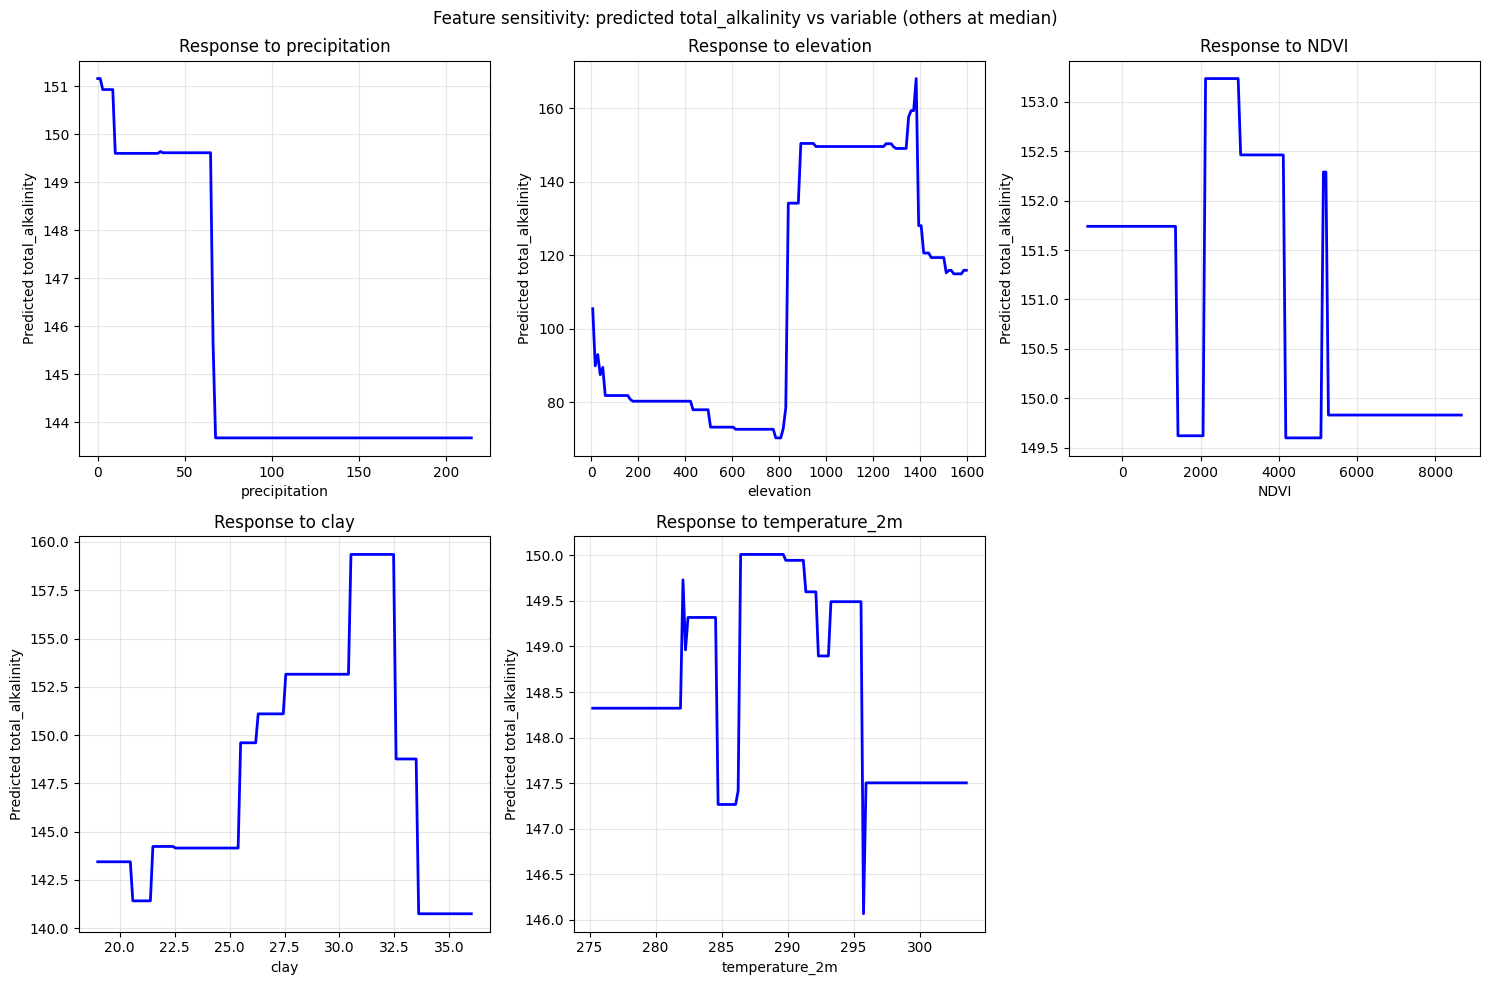

In [5]:
n_plot = len(key_vars)
fig, axes = plt.subplots(2, (n_plot + 1) // 2, figsize=(5 * ((n_plot + 1) // 2), 5 * 2))
axes = np.atleast_1d(axes).ravel()
for i, v in enumerate(key_vars):
    ax = axes[i]
    ax.plot(ranges[v], predictions[v], "b-", lw=2)
    ax.set_xlabel(v)
    ax.set_ylabel(f"Predicted {TARGET}")
    ax.set_title(f"Response to {v}")
    ax.grid(True, alpha=0.3)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Feature sensitivity: predicted total_alkalinity vs variable (others at median)")
plt.tight_layout()
plt.show()

# 6. Interpretation

## Environmental thresholds
- **Thresholds** are values of a predictor where the predicted response changes slope or level (e.g. a plateau, a steep rise, or a reversal). Look for kinks or inflection points in the curves; they may reflect process shifts (e.g. saturation, critical dilution, or changing dominance of a driver).

## Nonlinear responses
- **Nonlinear** curves (non-straight lines) show that the model has learned a non-additive effect: e.g. alkalinity rising with precipitation up to a point then flattening (dilution vs. weathering), or elevation showing a hump (mid-elevation maxima). Tree-based models (LightGBM) capture such patterns without assuming linearity.

## Implications for hydrology
- **Precipitation**: often relates to dilution (more rain → lower concentration) or to runoff and mobilization (more flow → more transport); the curve shape indicates which regime dominates in the learned relationship.
- **Elevation**: can proxy for geology, temperature, and rainfall gradients; response curves help separate altitudinal effects on weathering and flow paths.
- **NDVI / clay / temperature**: link vegetation, soil buffering, and reaction rates to water chemistry. Sensitivity analysis summarizes the **marginal** effect of each variable when others are fixed at typical (median) values; in the field, variables covary, so these are conditional relationships useful for process interpretation and scenario discussion.